In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [25]:
import numpy as np
import pandas as pd

# CSV 파일의 컬럼 이름 지정 (첫 번째 컬럼은 버릴 값이므로 "NaN"으로 명명)
names = ["NaN", "user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis"]

# CSV 파일 읽기 (header 없이, 첫 줄은 skip)
data = pd.read_csv("/Users/ohheungchan/workspace/AI_Study/paperwork/WISDM.csv",
                   header=None, names=names, skiprows=1)

# "NaN" 컬럼 제거
df = data.drop('NaN', axis=1)

# 'z_axis' 컬럼을 문자열로 변환 후 세미콜론(;) 제거
df["z_axis"] = df["z_axis"].astype(str).str.replace(';', '', regex=True)

# 문자열 데이터를 float으로 변환 (에러 발생 시 NaN으로 처리)
df["timestamp"] = pd.to_numeric(df["timestamp"], errors='coerce')
df["x_axis"]    = pd.to_numeric(df["x_axis"], errors='coerce')
df["y_axis"]    = pd.to_numeric(df["y_axis"], errors='coerce')
df["z_axis"]    = pd.to_numeric(df["z_axis"], errors='coerce')

# 결측치가 있는 행 제거
df.dropna(axis=0, how='any', inplace=True)

# 결과 확인
print(df.head())
print("DataFrame shape:", df.shape)

   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164
DataFrame shape: (1098203, 6)


In [26]:
# 타임스탬프를 기준으로 정렬한 후, 각 activity 그룹에서 마지막 24,000개 샘플을 test 셋으로 선택
test_df = data.groupby("activity", group_keys=False).apply(
    lambda x: x.sort_values("timestamp").tail(24000)
)

# test_df에 포함된 인덱스를 제외한 나머지를 train 셋으로 지정
train_df = data.drop(test_df.index)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# 각 그룹별 분포 확인 (타임스탬프 기반으로 분할한 경우에도 각 그룹의 샘플 수는 동일해야 함)
print("Train set activity distribution:")
print(train_df["activity"].value_counts())
print("\nTest set activity distribution:")
print(test_df["activity"].value_counts())

Train set shape: (954203, 7)
Test set shape: (144000, 7)
Train set activity distribution:
activity
Walking       400397
Jogging       318176
Upstairs       98869
Downstairs     76427
Sitting        35939
Standing       24395
Name: count, dtype: int64

Test set activity distribution:
activity
Downstairs    24000
Jogging       24000
Sitting       24000
Standing      24000
Upstairs      24000
Walking       24000
Name: count, dtype: int64


/var/folders/9x/8whwzmnj6z5bjc7_h1txd9_r0000gn/T/ipykernel_53758/3501039775.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = data.groupby("activity", group_keys=False).apply(


In [27]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import OneHotEncoder  # CrossEntropyLoss는 정수형 라벨을 사용하므로 OneHot은 필요없음

#############################################
# 1. 데이터 전처리 및 레이블 인코딩
#############################################
# df는 이미 'x_axis', 'y_axis', 'z_axis', 'activity' 컬럼을 가진 DataFrame이라고 가정합니다.
le = LabelEncoder()
train_df['ActivityEncoded'] = le.fit_transform(train_df['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)
le = LabelEncoder()
test_df['ActivityEncoded'] = le.fit_transform(test_df['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)

활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']
활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


In [28]:
train_df.activity.value_counts()

activity
Walking       400397
Jogging       318176
Upstairs       98869
Downstairs     76427
Sitting        35939
Standing       24395
Name: count, dtype: int64

<Axes: xlabel='activity', ylabel='count'>

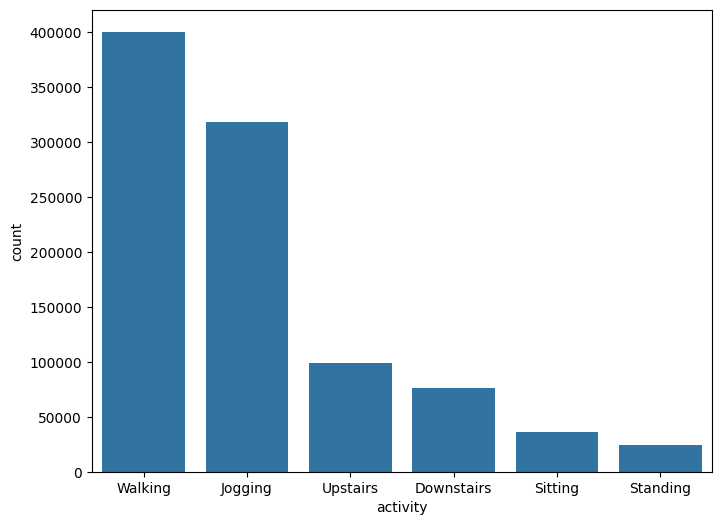

In [29]:
plt.figure(figsize=(8, 6))
sns.countplot(x = "activity", data = train_df, order = train_df.activity.value_counts().index)
     

In [30]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

#############################################
# 1. Diffusion 모델 관련 함수 정의 (WISDM 데이터에 적용)
#############################################
def train_diffusion_model(sensor_data, epochs=500, lr=0.001, timesteps=10):
    """
    sensor_data: numpy array, shape (N, 3) – 해당 클래스의 센서 데이터 (WISDM 데이터셋의 경우 'x_axis', 'y_axis', 'z_axis')
    epochs: 학습 에포크 수
    lr: 학습률
    timesteps: Diffusion 과정의 단계 수
    """
    # 디바이스 설정: Apple Silicon(MPS) > CUDA > CPU
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"Diffusion 모델 학습 시 사용 device: {device}")
    
    # UNet1D 모델 정의 (내부에 간단한 1D Convolution 블록)
    class UNet1D(nn.Module):
        def __init__(self, input_dim=3):
            super(UNet1D, self).__init__()
            self.encoder = nn.Sequential(
                nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.ReLU()
            )
            self.bottleneck = nn.Sequential(
                nn.Conv1d(128, 128, kernel_size=3, padding=1),
                nn.ReLU()
            )
            self.decoder = nn.Sequential(
                nn.Conv1d(128, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(64, input_dim, kernel_size=3, padding=1)
            )
            
        def forward(self, x, t):
            x = self.encoder(x)
            x = self.bottleneck(x)
            x = self.decoder(x)
            return x

    model = UNet1D(input_dim=3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # sensor_data: (N, 3) → (N, 3, 1)
    sensor_data = torch.tensor(sensor_data, dtype=torch.float32).unsqueeze(-1).to(device)
    beta_schedule = np.linspace(0.0001, 0.02, timesteps)
    
    for epoch in tqdm(range(epochs), desc='Training Diffusion Model'):
        optimizer.zero_grad()
        idx = torch.randint(0, sensor_data.shape[0], (32,))
        x = sensor_data[idx]
        # forward diffusion: 각 단계마다 노이즈를 추가하는 과정
        x_noisy = []
        noise_levels = np.cumprod(1 - beta_schedule)
        for t in range(timesteps):
            noise = torch.randn_like(x) * torch.sqrt(torch.tensor(beta_schedule[t], dtype=torch.float32))
            noisy_x = torch.sqrt(torch.tensor(noise_levels[t], dtype=torch.float32)) * x + noise
            x_noisy.append(noisy_x)
        t_choice = torch.randint(0, timesteps, (1,)).item()
        noisy_x = x_noisy[t_choice]
        predicted_x = model(noisy_x, t_choice)
        loss = criterion(predicted_x, x)
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0:
            print(f"Epoch {epoch}/{epochs} - Loss: {loss.item():.6f}")
    return model

def generate_synthetic_data(model, num_samples=100, timesteps=10):
    """
    model: 학습된 Diffusion 모델
    num_samples: 생성할 합성 데이터 수
    timesteps: Diffusion 단계 수 (train_diffusion_model와 동일)
    """
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    model.to(device)
    model.eval()
    beta_schedule = np.linspace(0.0001, 0.02, timesteps)
    noise_levels = np.cumprod(1 - beta_schedule)
    with torch.no_grad():
        synthetic_data = torch.randn((num_samples, 3, 1), dtype=torch.float32).to(device)
        # 역방향 diffusion 과정을 단순 모방
        for t in reversed(range(timesteps)):
            predicted_x = model(synthetic_data, t)
            noise = torch.randn_like(predicted_x) * torch.sqrt(torch.tensor(beta_schedule[t], dtype=torch.float32))
            synthetic_data = (predicted_x - noise) / torch.sqrt(torch.tensor(noise_levels[t], dtype=torch.float32))
    return synthetic_data.squeeze(-1).cpu().numpy()


In [31]:
#############################################
# 2. SMOTE + Diffusion을 이용한 데이터 밸런싱 함수 (WISDM 데이터셋 적용)
#############################################
def balance_dataset_smote_diffusion(train_df, target_count=500000, noise_dim=16, batch_size=32, diffusion_epochs=50):
    """
    train_df: 원본 트레인 데이터프레임 (컬럼: 'x_axis', 'y_axis', 'z_axis', 'activity')
    target_count: 각 클래스별 최종 목표 샘플 수 (예: 500,000)
    SMOTE로 80% 보충 후, 나머지 20%는 Diffusion으로 증강
    diffusion_epochs: Diffusion 모델 학습 에포크 수 (속도 개선을 위해 조정 가능)
    """
    # 라벨 인코딩: activity 컬럼 -> activity_encoded
    le = LabelEncoder()
    train_df['activity_encoded'] = le.fit_transform(train_df['activity'])
    
    # SMOTE 적용
    X_train_values = train_df[['x_axis', 'y_axis', 'z_axis']].values
    y_train_encoded = train_df['activity_encoded'].values
    
    # 각 클래스별 현재 샘플 수 계산
    counts = pd.Series(y_train_encoded).value_counts().sort_index()
    print("SMOTE 전 각 클래스별 샘플 수:")
    for cls, cnt in zip(le.inverse_transform(counts.index), counts.values):
        print(f"{cls}: {cnt}")
    max_count = target_count  # 목표 수 (예: 500,000)
    
    # SMOTE 목표: 각 클래스별 목표 = 기존 count + (target_count - count)*0.8
    sampling_strategy = {}
    diffusion_counts = {}  # Diffusion으로 증강할 샘플 수
    for cls, cnt in counts.items():
        if cnt < target_count:
            diff = target_count - cnt
            smote_target = cnt + int(diff * 0.8)
            sampling_strategy[cls] = smote_target
            diffusion_counts[cls] = target_count - smote_target
    print("SMOTE Sampling Strategy:", sampling_strategy)
    print("Diffusion 증강 개수:", diffusion_counts)
    
    if sampling_strategy:
        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
        X_smote, y_smote = smote.fit_resample(X_train_values, y_train_encoded)
    else:
        X_smote, y_smote = X_train_values, y_train_encoded
    
    # SMOTE 결과를 DataFrame으로 변환
    df_smote = pd.DataFrame(X_smote, columns=['x_axis','y_axis','z_axis'])
    df_smote['activity_encoded'] = y_smote
    df_smote['activity'] = le.inverse_transform(y_smote)
    
    # 디바이스 설정 (Diffusion 모델 학습에 사용)
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print("Using device for Diffusion:", device)
    
    augmented_dfs = []
    
    # 각 클래스별로 Diffusion 증강 진행 (목표: 각 클래스별 target_count까지)
    for cls in sorted(df_smote['activity_encoded'].unique()):
        df_cls = df_smote[df_smote['activity_encoded'] == cls].copy()
        current_count = df_cls.shape[0]
        original_count = train_df[train_df['activity_encoded'] == cls].shape[0]
        deficit = target_count - current_count
        original_label = le.inverse_transform([cls])[0]
        print(f"클래스 '{original_label}' - 원본: {original_count}, SMOTE 후: {current_count}, 부족: {deficit}")
        
        if deficit > 0 and diffusion_counts.get(cls, 0) > 0:
            diff_count = diffusion_counts[cls]
            print(f" -> 클래스 '{original_label}': Diffusion 증강 {diff_count} samples")
            sensor_data = df_cls[['x_axis', 'y_axis', 'z_axis']].values
            if sensor_data.shape[0] == 0:
                print(f"   클래스 '{original_label}'에 대해 센서 데이터가 없습니다. Diffusion 증강 건너뜁니다.")
                df_diff = pd.DataFrame(columns=['x_axis', 'y_axis', 'z_axis'])
            else:
                diffusion_model = train_diffusion_model(sensor_data, epochs=diffusion_epochs, lr=0.001, timesteps=10)
                synthetic_data = generate_synthetic_data(diffusion_model, num_samples=diff_count, timesteps=10)
                df_diff = pd.DataFrame(synthetic_data, columns=['x_axis', 'y_axis', 'z_axis'])
                df_diff['activity_encoded'] = cls
                df_diff['activity'] = original_label
            df_cls = pd.concat([df_cls, df_diff], axis=0)
        else:
            print(f"클래스 '{original_label}'는 Diffusion 증강 불필요")
        
        # 최종적으로 부족한 경우 랜덤 오버샘플링으로 채움
        final_count = df_cls.shape[0]
        if final_count < target_count:
            extra = target_count - final_count
            df_extra = df_cls.sample(n=extra, replace=True, random_state=42)
            df_cls = pd.concat([df_cls, df_extra], axis=0)
        augmented_dfs.append(df_cls)
    
    df_balanced = pd.concat(augmented_dfs, axis=0).reset_index(drop=True)
    print("최종 증강된 트레인셋 shape:", df_balanced.shape)
    print("최종 증강된 트레인셋 클래스별 샘플 수:")
    print(df_balanced['activity'].value_counts())
    return df_balanced

In [32]:
# SMOTE로 80% 보충 후, Diffusion으로 20% 증강하여 각 클래스별 목표 샘플 수(target_count, 예: 400397)로 맞추기
df_train_augmented = balance_dataset_smote_diffusion(train_df, target_count=400397, noise_dim=16, batch_size=32, diffusion_epochs=50)
print("밸런싱된 트레인 데이터셋 shape:", df_train_augmented.shape)
print("클래스별 샘플 수:")
print(df_train_augmented['activity'].value_counts())

SMOTE 전 각 클래스별 샘플 수:
Downstairs: 76427
Jogging: 318176
Sitting: 35939
Standing: 24395
Upstairs: 98869
Walking: 400397
SMOTE Sampling Strategy: {0: 335603, 1: 383952, 2: 327505, 3: 325196, 4: 340091}
Diffusion 증강 개수: {0: 64794, 1: 16445, 2: 72892, 3: 75201, 4: 60306}


/Users/ohheungchan/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/ohheungchan/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Using device for Diffusion: mps
클래스 'Downstairs' - 원본: 76427, SMOTE 후: 335603, 부족: 64794
 -> 클래스 'Downstairs': Diffusion 증강 64794 samples
Diffusion 모델 학습 시 사용 device: mps


Training Diffusion Model:  30%|████▊           | 15/50 [00:00<00:00, 149.93it/s]

Epoch 0/50 - Loss: 31.259466


...

클래스 'Upstairs' - 원본: 98869, SMOTE 후: 340091, 부족: 60306
 -> 클래스 'Upstairs': Diffusion 증강 60306 samples
Diffusion 모델 학습 시 사용 device: mps


Training Diffusion Model:  50%|████████        | 25/50 [00:00<00:00, 247.44it/s]

Epoch 0/50 - Loss: 48.605133



raining Diffusion Model: 100%|████████████████| 50/50 [00:00<00:00, 254.92it/s]

클래스 'Walking' - 원본: 400397, SMOTE 후: 400397, 부족: 0
클래스 'Walking'는 Diffusion 증강 불필요
최종 증강된 트레인셋 shape: (2402382, 5)
최종 증강된 트레인셋 클래스별 샘플 수:
activity
Downstairs    400397
Jogging       400397
Sitting       400397
Standing      400397
Upstairs      400397
Walking       400397
Name: count, dtype: int64
밸런싱된 트레인 데이터셋 shape: (2402382, 5)
클래스별 샘플 수:
activity
Downstairs    400397
Jogging       400397
Sitting       400397
Standing      400397
Upstairs      400397
Walking       400397
Name: count, dtype: int64


In [33]:
le = LabelEncoder()
df_train_augmented['ActivityEncoded'] = le.fit_transform(df_train_augmented['activity'])
num_classes = len(le.classes_)
print("활동 클래스:", le.classes_)

활동 클래스: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


<Axes: xlabel='ActivityEncoded', ylabel='count'>

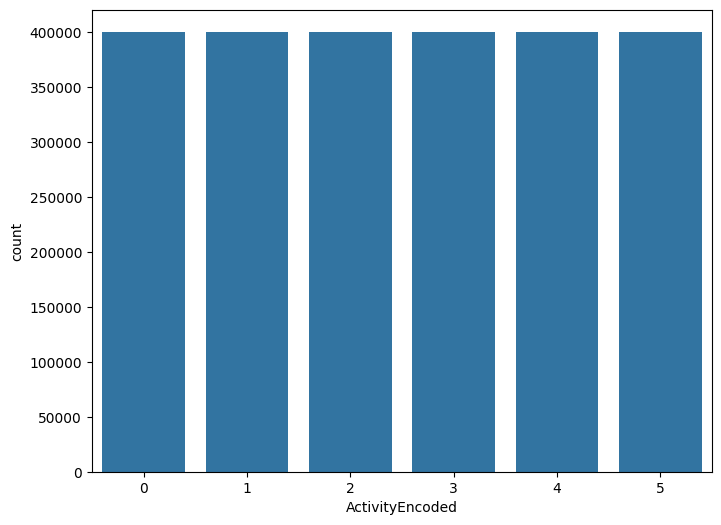

In [34]:
plt.figure(figsize=(8, 6))
sns.countplot(x = "ActivityEncoded", data = df_train_augmented, order = df_train_augmented.ActivityEncoded.value_counts().index)
     

In [35]:
#############################################
# 2. 시계열 데이터 세그먼테이션 함수 정의
#############################################
def create_dataset(X, y, time_steps=1, step=1):
    """
    X: 센서 데이터가 담긴 DataFrame (예: ["x_axis", "y_axis", "z_axis"])
    y: 라벨(인코딩된 값)이 담긴 Series (예: df["ActivityEncoded"])
    time_steps: 각 시퀀스(윈도우)의 길이 (예: 200)
    step: 윈도우 생성 시 이동 간격 (예: 40)
    """
    Xs, ys = [], []
    for i in range(0, len(X) - time_steps, step):
        # i부터 i+time_steps까지의 센서 데이터를 numpy 배열로 변환
        v = X.iloc[i:(i + time_steps)].values
        # 해당 구간의 라벨들을 선택하고, 다수결(mode)로 대표 라벨 결정
        window_labels = y.iloc[i:(i + time_steps)]
        mode_result = stats.mode(window_labels)
        mode_label = mode_result.mode
        # 만약 mode_label이 배열이면 첫 번째 원소 선택
        if isinstance(mode_label, np.ndarray):
            mode_label = mode_label[0]
        Xs.append(v)
        ys.append(mode_label)
    return np.array(Xs), np.array(ys).reshape(-1, 1)

In [36]:
#최반값으로. 라벨
TIME_STEPS = 200  # 각 윈도우(시퀀스)의 길이
STEP = 40
X_train, y_train = create_dataset(
    df_train_augmented[["x_axis", "y_axis", "z_axis"]],
    df_train_augmented["ActivityEncoded"],
    time_steps=TIME_STEPS,
    step=STEP
)

X_test, y_test = create_dataset(
    test_df[["x_axis", "y_axis", "z_axis"]],
    test_df["ActivityEncoded"],
    time_steps=TIME_STEPS,
    step=STEP
)

# 3. train셋에서 validation셋 분리 (train 데이터의 일부를 validation으로 사용)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (48044, 200, 3) (48044, 1)
Validation shape: (12011, 200, 3) (12011, 1)
Test shape: (3595, 200, 3) (3595, 1)


In [37]:
#############################################
# 4. PyTorch DataLoader 준비
#############################################
import torch
from torch.utils.data import DataLoader, TensorDataset

def prepare_loader(X, y, batch_size=64):
    # CNN 모델 입력은 (batch, channels, length) → 변환: (N, window_size, 3) → (N, 3, window_size)
    X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
    # y는 정수형 라벨, shape (N,1) -> squeeze하여 (N,)
    y_tensor = torch.tensor(y, dtype=torch.long).squeeze()
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

train_loader = prepare_loader(X_train, y_train, batch_size=64)
val_loader = prepare_loader(X_val, y_val, batch_size=64)
test_loader = prepare_loader(X_test, y_test, batch_size=64)


In [38]:

#############################################
# 5. 간단한 1D CNN 분류기 정의
#############################################
import torch.nn as nn
import torch.optim as optim

# Device 설정 (MPS, CUDA 또는 CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple GPU)")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, window_size=200):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * (window_size // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Using device: MPS (Apple GPU)


In [ ]:
#############################################
# 6. 모델 학습 및 평가
#############################################
num_epochs = 50  # 학습 에폭 수
window_size=200
model = SimpleCNN(num_classes=num_classes, window_size=window_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("\n=== 모델 학습 시작 ===")
# 에폭별 손실과 정확도를 저장할 리스트
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == y_batch)
        total_train += y_batch.size(0)
    
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc.item())
    
    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    total_val = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_running_loss += loss.item() * X_val.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == y_val)
            total_val += y_val.size(0)
    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = val_running_corrects.float() / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")



=== 모델 학습 시작 ===
Epoch 1/50, Train Loss: 0.3233, Train Acc: 0.8772, Val Loss: 0.1625, Val Acc: 0.9406
Epoch 2/50, Train Loss: 0.1090, Train Acc: 0.9611, Val Loss: 0.0774, Val Acc: 0.9730
Epoch 3/50, Train Loss: 0.0610, Train Acc: 0.9777, Val Loss: 0.0643, Val Acc: 0.9787
Epoch 4/50, Train Loss: 0.0409, Train Acc: 0.9857, Val Loss: 0.0634, Val Acc: 0.9793
Epoch 5/50, Train Loss: 0.0292, Train Acc: 0.9900, Val Loss: 0.0539, Val Acc: 0.9820
Epoch 6/50, Train Loss: 0.0266, Train Acc: 0.9905, Val Loss: 0.0910, Val Acc: 0.9727
Epoch 7/50, Train Loss: 0.0191, Train Acc: 0.9933, Val Loss: 0.0563, Val Acc: 0.9818
Epoch 8/50, Train Loss: 0.0155, Train Acc: 0.9950, Val Loss: 0.0664, Val Acc: 0.9814
Epoch 9/50, Train Loss: 0.0163, Train Acc: 0.9949, Val Loss: 0.0569, Val Acc: 0.9835
Epoch 10/50, Train Loss: 0.0131, Train Acc: 0.9957, Val Loss: 0.0547, Val Acc: 0.9844
Epoch 11/50, Train Loss: 0.0163, Train Acc: 0.9952, Val Loss: 0.0544, Val Acc: 0.9849
Epoch 12/50, Train Loss: 0.0115, Train Acc: 0

In [ ]:
# 학습 및 검증 결과 플롯팅
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 손실 플롯
plt.subplot(1, 2, 1)


plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

# 정확도 플롯
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o', label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze()  # 만약 y_batch가 (batch_size, 1)이라면
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"테스트 정확도: {accuracy:.2f}%")

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# LABELS는 클래스 이름을 지정합니다.
LABELS = ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']

# 모델을 평가 모드로 전환
model.eval()

# 전체 test 데이터에 대해 예측값과 정답을 모읍니다.
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)
        # 각 샘플에 대해 가장 높은 확률을 가진 클래스 인덱스 선택
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

# 혼동 행렬 계산
cm = confusion_matrix(all_true, all_preds)

# 평가 지표 출력
print("F1 Score (weighted):", f1_score(all_true, all_preds, average='weighted'))
print("Accuracy:", accuracy_score(all_true, all_preds))
print("Classification Report:")
print(classification_report(all_true, all_preds, target_names=LABELS))

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap="YlGnBu", xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()